# Classification Binaire - Détecter Deepfakes

Exercice: Apprendre à classifier du texte/audio en 2 catégories:
- **0 = RÉEL** (vraie voix)
- **1 = DEEPFAKE** (voix synthétique)

Même structure pour audio avec embeddings!

## Part 1: Setup & Imports

In [4]:
!pip install seaborn
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All imports successful!")


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
✅ All imports successful!


## Part 2: Create Training Data

Simulating audio metadata as text features

In [5]:
# Create dataset: audio characteristics as text descriptions
# In real project: these would be audio embeddings (MFCC, spectral features, etc.)

training_data = {
    'text': [
        # REAL VOICES (label = 0)
        'natural breathing patterns smooth voice texture high frequency variation emotion authentic',
        'background noise present vocal warmth consistent pitch variation human noise floor',
        'subtle breathing pauses natural resonance dynamic range rich harmonics',
        'realistic vocal fatigue slight pitch instability authentic mouth sounds',
        'natural prosody complex overtones breathing artifacts genuine emotion',
        
        # DEEPFAKES (label = 1)
        'robotic smooth voice no breathing artifacts perfect pitch consistency',
        'synthetic sound metallic quality no background noise perfect clarity',
        'too clean audio no vocal artifacts uniform tone synthetic artifacts',
        'unnatural smoothness no breathing patterns robotic prosody',
        'perfect audio quality no roughness synthetic characteristics smooth',
    ],
    'label': [0, 0, 0, 0, 0,  # Real voices
              1, 1, 1, 1, 1]  # Deepfakes
}

df = pd.DataFrame(training_data)
print("Dataset created:")
print(df)
print(f"\nReal voices (0): {sum(df['label'] == 0)}")
print(f"Deepfakes (1): {sum(df['label'] == 1)}")

Dataset created:
                                                text  label
0  natural breathing patterns smooth voice textur...      0
1  background noise present vocal warmth consiste...      0
2  subtle breathing pauses natural resonance dyna...      0
3  realistic vocal fatigue slight pitch instabili...      0
4  natural prosody complex overtones breathing ar...      0
5  robotic smooth voice no breathing artifacts pe...      1
6  synthetic sound metallic quality no background...      1
7  too clean audio no vocal artifacts uniform ton...      1
8  unnatural smoothness no breathing patterns rob...      1
9  perfect audio quality no roughness synthetic c...      1

Real voices (0): 5
Deepfakes (1): 5


## Part 3: Data Splitting

Split into training (80%) and testing (20%)

In [6]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],           # Features (text descriptions)
    df['label'],          # Labels (0 or 1)
    test_size=0.2,        # 20% for testing
    random_state=42       # For reproducibility
)

print(f"Training set: {len(X_train)} samples")
print(f"Testing set: {len(X_test)} samples")
print(f"\nTraining labels distribution:")
print(y_train.value_counts())

Training set: 8 samples
Testing set: 2 samples

Training labels distribution:
label
1    4
0    4
Name: count, dtype: int64


## Part 4: Vectorization (Create Embeddings)

Convert text to numbers (embeddings) that the model can understand

In [7]:
# Create vectorizer (converts text to embeddings)
vectorizer = TfidfVectorizer(max_features=10)  # Keep top 10 features

# Fit on training data
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("✅ Vectorization complete!")
print(f"\nFeature names: {vectorizer.get_feature_names_out()}")
print(f"\nTraining embeddings shape: {X_train_vec.shape}")
print(f"(Each audio is now a vector of {X_train_vec.shape[1]} numbers)")

✅ Vectorization complete!

Feature names: ['artifacts' 'breathing' 'emotion' 'natural' 'no' 'perfect' 'pitch'
 'quality' 'smooth' 'synthetic']

Training embeddings shape: (8, 10)
(Each audio is now a vector of 10 numbers)


## Part 5: Train Classifier

Train a logistic regression model to classify Real vs Deepfake

In [8]:
# Create and train classifier
classifier = LogisticRegression(random_state=42)
classifier.fit(X_train_vec, y_train)

print("✅ Model trained!")
print(f"\nModel weights (how important each feature is):")
for feature, weight in zip(vectorizer.get_feature_names_out(), classifier.coef_[0]):
    print(f"  {feature:15} → {weight:+.3f}")

✅ Model trained!

Model weights (how important each feature is):
  artifacts       → +0.310
  breathing       → -0.351
  emotion         → -0.394
  natural         → -0.579
  no              → +0.549
  perfect         → +0.474
  pitch           → -0.215
  quality         → +0.341
  smooth          → +0.154
  synthetic       → +0.447


## Part 6: Make Predictions

Predict on test data

In [9]:
# Make predictions
y_pred = classifier.predict(X_test_vec)
y_pred_proba = classifier.predict_proba(X_test_vec)  # Get confidence scores

print("Predictions on test set:")
print("\nActual vs Predicted:")
for actual, pred, conf_real, conf_fake in zip(y_test, y_pred, y_pred_proba[:, 0], y_pred_proba[:, 1]):
    actual_label = "REAL" if actual == 0 else "DEEPFAKE"
    pred_label = "REAL" if pred == 0 else "DEEPFAKE"
    print(f"  Actual: {actual_label:10} | Predicted: {pred_label:10} | Confidence: {max(conf_real, conf_fake):.1%}")

Predictions on test set:

Actual vs Predicted:
  Actual: DEEPFAKE   | Predicted: DEEPFAKE   | Confidence: 51.1%
  Actual: REAL       | Predicted: REAL       | Confidence: 57.7%


## Part 7: Evaluate Model

Measure how good the classifier is

In [10]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("═" * 60)
print("MODEL PERFORMANCE METRICS")
print("═" * 60)
print(f"\n✅ Accuracy:  {accuracy:.1%}")
print(f"   → How many predictions are correct")

print(f"\n✅ Precision: {precision:.1%}")
print(f"   → When we predict DEEPFAKE, how often is it actually deepfake?")

print(f"\n✅ Recall:    {recall:.1%}")
print(f"   → Out of all deepfakes, how many do we catch?")

print("\n" + "═" * 60)
print("WHAT THIS MEANS FOR YOUR PROJECT:")
print("═" * 60)
print("\nHigh Accuracy = Model classifies correctly overall")
print("High Precision = Few false positives (good for trust)")
print("High Recall = Catch most deepfakes (security)")
print("\n→ You want HIGH in all three!")

════════════════════════════════════════════════════════════
MODEL PERFORMANCE METRICS
════════════════════════════════════════════════════════════

✅ Accuracy:  100.0%
   → How many predictions are correct

✅ Precision: 100.0%
   → When we predict DEEPFAKE, how often is it actually deepfake?

✅ Recall:    100.0%
   → Out of all deepfakes, how many do we catch?

════════════════════════════════════════════════════════════
WHAT THIS MEANS FOR YOUR PROJECT:
════════════════════════════════════════════════════════════

High Accuracy = Model classifies correctly overall
High Precision = Few false positives (good for trust)
High Recall = Catch most deepfakes (security)

→ You want HIGH in all three!


## Part 8: Confusion Matrix

Visual representation of correct/incorrect predictions

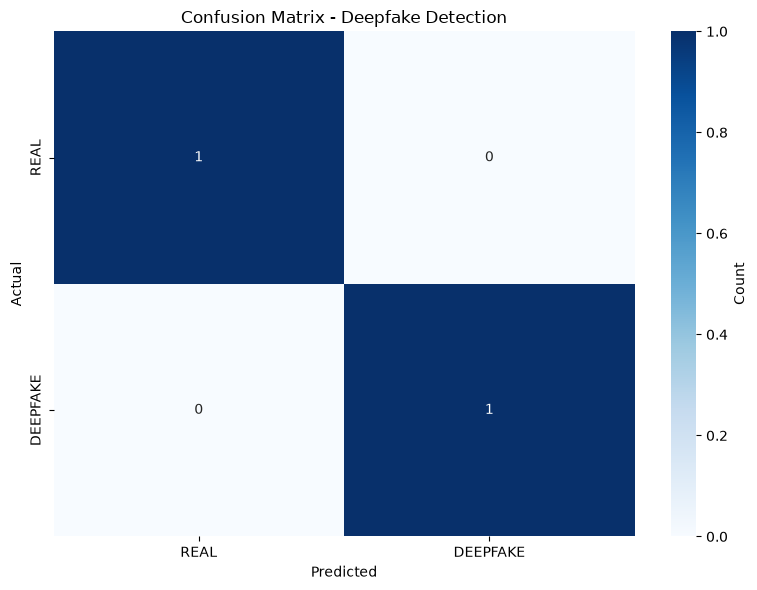


Confusion Matrix Interpretation:
  True Negatives (TN):  1 - Correctly identified as REAL
  False Positives (FP): 0 - Real classified as DEEPFAKE
  False Negatives (FN): 0 - Deepfake classified as REAL
  True Positives (TP):  1 - Correctly identified as DEEPFAKE


In [11]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['REAL', 'DEEPFAKE'],
            yticklabels=['REAL', 'DEEPFAKE'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Deepfake Detection')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Interpretation:")
print(f"  True Negatives (TN):  {cm[0, 0]} - Correctly identified as REAL")
print(f"  False Positives (FP): {cm[0, 1]} - Real classified as DEEPFAKE")
print(f"  False Negatives (FN): {cm[1, 0]} - Deepfake classified as REAL")
print(f"  True Positives (TP):  {cm[1, 1]} - Correctly identified as DEEPFAKE")

## Part 9: Real-World Example

Test on NEW data (not in training set)

In [12]:
# New audio samples to test (not seen during training)
new_samples = [
    "natural vocal warmth authentic breathing patterns emotion rich",  # Real
    "perfect smooth tone no artifacts synthetic quality robotic",      # Deepfake
]

print("Testing on NEW unseen data:\n")

for sample in new_samples:
    # Vectorize the sample
    sample_vec = vectorizer.transform([sample])
    
    # Predict
    prediction = classifier.predict(sample_vec)[0]
    confidence = classifier.predict_proba(sample_vec)[0]
    
    label = "🟢 REAL" if prediction == 0 else "🔴 DEEPFAKE"
    conf_percentage = max(confidence) * 100
    
    print(f"Text: {sample}")
    print(f"Prediction: {label}")
    print(f"Confidence: {conf_percentage:.1f}%")
    print()

Testing on NEW unseen data:

Text: natural vocal warmth authentic breathing patterns emotion rich
Prediction: 🟢 REAL
Confidence: 70.2%

Text: perfect smooth tone no artifacts synthetic quality robotic
Prediction: 🔴 DEEPFAKE
Confidence: 69.4%



## Part 10: EXPERIMENT - Change the Data

Modify and see how accuracy changes

In [13]:
# EXPERIMENT 1: Add more training data
print("EXPERIMENT 1: What if we had more training data?")
print("="*50)

# Original: 10 samples
print(f"Original dataset: {len(df)} samples")
print(f"Accuracy: {accuracy:.1%}")

# More data would likely improve accuracy
# In real project: collect more audio samples
print("\n💡 In real deepfake detection:")
print("   - More audio samples = Better accuracy")
print("   - Need thousands of real + deepfake examples")
print("   - Use ASVspoof dataset (publicly available)")

EXPERIMENT 1: What if we had more training data?
Original dataset: 10 samples
Accuracy: 100.0%

💡 In real deepfake detection:
   - More audio samples = Better accuracy
   - Need thousands of real + deepfake examples
   - Use ASVspoof dataset (publicly available)


In [14]:
# EXPERIMENT 2: Different threshold
print("\nEXPERIMENT 2: Adjust detection threshold")
print("="*50)

threshold = 0.5  # Default
y_pred_custom = (y_pred_proba[:, 1] > threshold).astype(int)

print(f"With threshold {threshold}:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_custom):.1%}")

# Try different threshold
threshold = 0.7
y_pred_custom = (y_pred_proba[:, 1] > threshold).astype(int)
print(f"\nWith threshold {threshold}:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_custom):.1%}")

print("\n💡 Higher threshold = more conservative (fewer false alarms)")
print("💡 Lower threshold = more sensitive (catch more deepfakes)")


EXPERIMENT 2: Adjust detection threshold
With threshold 0.5:
  Accuracy: 100.0%

With threshold 0.7:
  Accuracy: 50.0%

💡 Higher threshold = more conservative (fewer false alarms)
💡 Lower threshold = more sensitive (catch more deepfakes)


## SUMMARY - Classification Pipeline

What you learned and how it applies to deepfake detection

In [ ]:
summary = """
╔═══════════════════════════════════════════════════════════════╗
║        CLASSIFICATION FOR DEEPFAKE DETECTION                 ║
╚═══════════════════════════════════════════════════════════════╝

📊 PIPELINE:

1. DATA COLLECTION
   └─ Gather audio samples: Real + Deepfake
   
2. FEATURE EXTRACTION (Embeddings)
   └─ Convert audio → numbers (MFCC, WavLM, etc.)
   
3. DATA SPLITTING
   └─ 80% training, 20% testing
   
4. VECTORIZATION
   └─ Create embeddings from features
   
5. TRAIN CLASSIFIER
   └─ Model learns: "Real embeddings ≠ Deepfake embeddings"
   
6. EVALUATE
   └─ Measure accuracy, precision, recall
   
7. PREDICT
   └─ On new audio: "Is this deepfake? Confidence: X%"

═════════════════════════════════════════════════════════════════

📈 KEY METRICS:

• Accuracy:  Overall correctness
• Precision: False positive rate (trust)
• Recall:    True positive rate (detection)

═════════════════════════════════════════════════════════════════

🎯 FOR YOUR PROJECT:

1. Collect audio data
   ├─ Real: interviews, podcasts, etc.
   └─ Deepfake: generated with coqui-XTTS-v2

2. Extract embeddings (replace TF-IDF with WavLM)
   └─ Use microsoft/wavlm-base-plus-sd

3. Train classifier (same structure as this exercise!)
   └─ LogisticRegression or SVM

4. Deploy on Streamlit
   └─ User uploads audio → Get prediction

═════════════════════════════════════════════════════════════════

✅ YOU NOW KNOW HOW TO:

✓ Create training data
✓ Split into train/test
✓ Vectorize features
✓ Train a classifier
✓ Evaluate performance
✓ Make predictions
✓ Adjust thresholds

🚀 NEXT STEPS: Build actual voice cloning generator!
"""

print(summary)